In [ ]:
'''Today I learned Matplotlib, Seaborn, and Plotly for data visualization in Python. I practiced creating bar charts, line charts, histograms, scatter plots, and correlation heatmaps using the Supply Chain Dataset.'''

In [1]:
from google.colab import files

uploaded = files.upload()

Saving supply_chain_data.csv to supply_chain_data.csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("supply_chain_data.csv")

In [4]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
df.shape

(100, 24)

In [6]:
df.isnull().sum()

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [12]:
print(df.columns)

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'lead_times', 'order_quantities', 'shipping_times',
       'shipping_carriers', 'shipping_costs', 'supplier_name', 'location',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'inspection_results', 'defect_rates',
       'transportation_modes', 'routes', 'costs'],
      dtype='object')


In [16]:
revenue = df.groupby('product_type')['revenue_generated'].sum()

In [15]:
import matplotlib.pyplot as plt

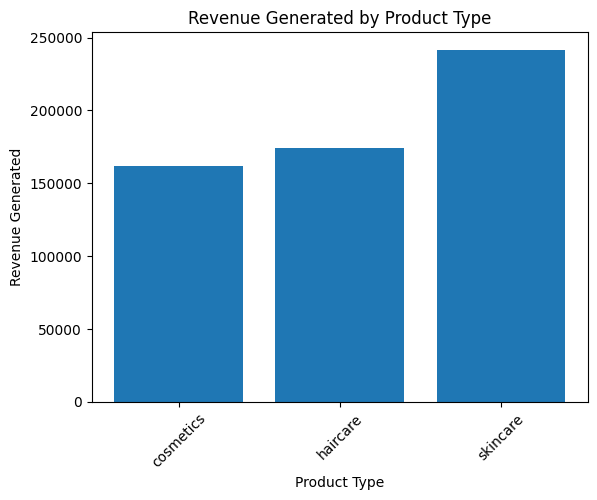

In [21]:
# Bar Plot
plt.bar(revenue.index,revenue.values)
plt.xlabel('Product Type')
plt.ylabel('Revenue Generated')
plt.title('Revenue Generated by Product Type')
plt.xticks(rotation=45)
plt.show()

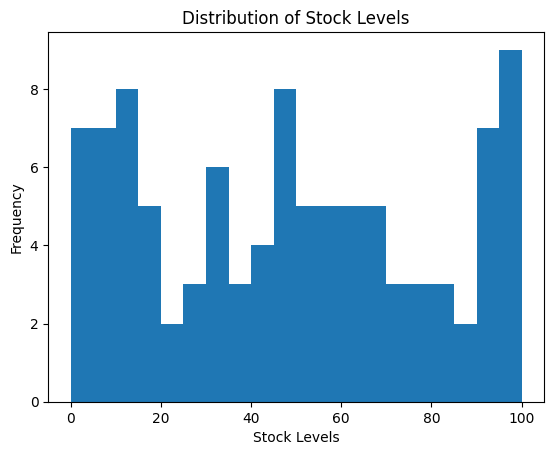

In [23]:
# Histogram
plt.hist(df['stock_levels'],bins=20)
plt.xlabel('Stock Levels')
plt.ylabel('Frequency')
plt.title('Distribution of Stock Levels')
plt.show()

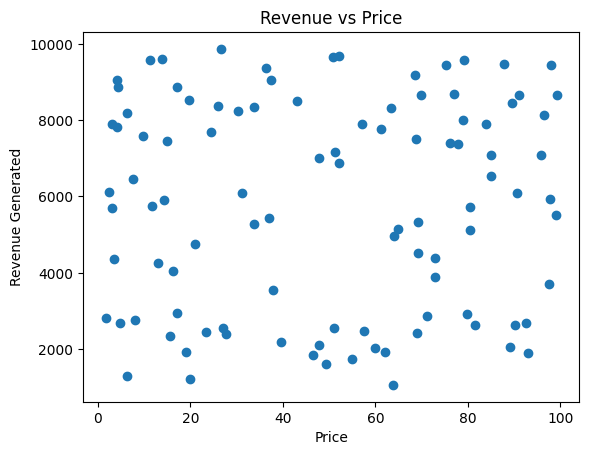

In [25]:
# Scatter plot
plt.scatter(df['price'],df['revenue_generated'])
plt.xlabel('Price')
plt.ylabel('Revenue Generated')
plt.title('Revenue vs Price')
plt.show()

In [26]:
import seaborn as sns

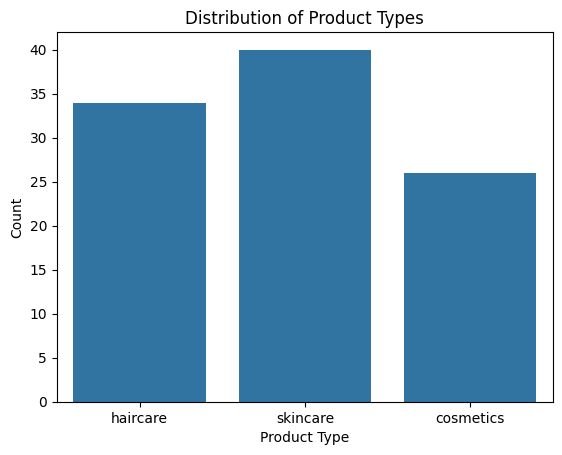

In [27]:
#countplot
sns.countplot(data=df,x='product_type')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.title('Distribution of Product Types')
plt.show()

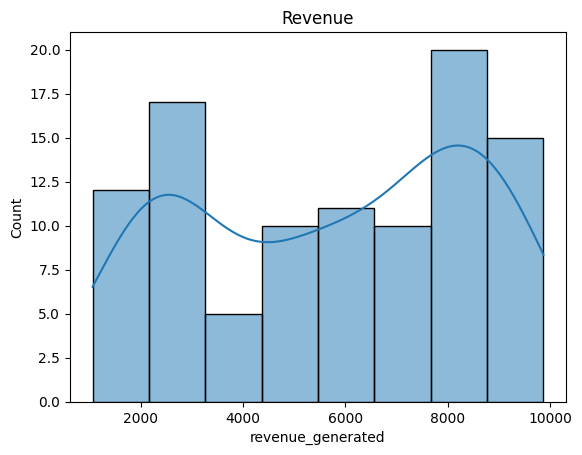

In [28]:
# Histogram
sns.histplot(data=df,x='revenue_generated',kde=True)
plt.title('Revenue')
plt.show()

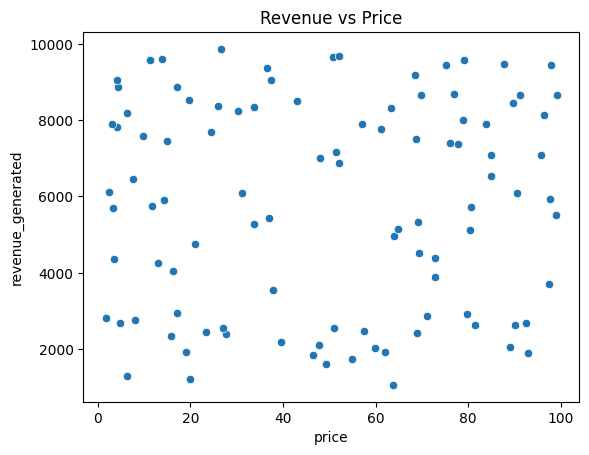

In [29]:
# Scatter Plot
sns.scatterplot(data=df,x='price',y='revenue_generated')
plt.title('Revenue vs Price')
plt.show()

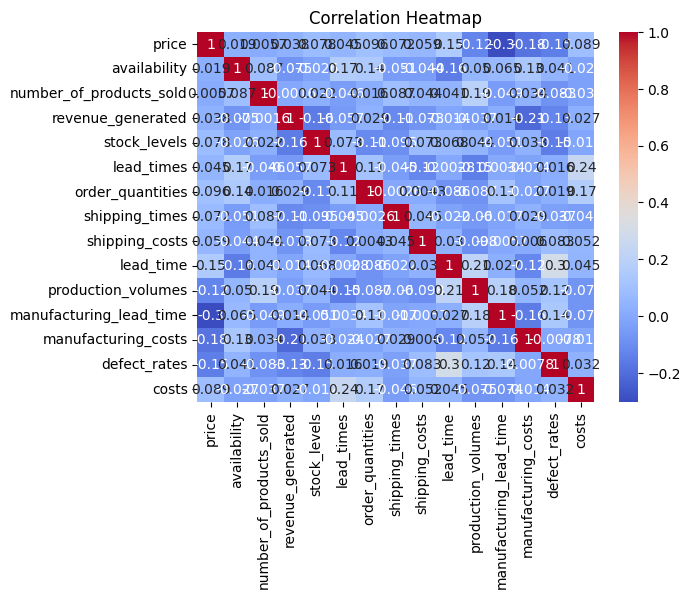

In [31]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [32]:
import plotly.express as px

In [37]:
fig = px.bar(
    df,
    x='product_type',
    y='revenue_generated'
)

fig.show()

In [39]:
fig = px.scatter(
    df,
    x='price',
    y='revenue_generated',
    color='product_type',
    hover_data=df.columns
)

fig.show()

In [41]:
fig = px.histogram(
    df,
    x='stock_levels',
    color='product_type',
    title='Stock Level Distribution'
)

fig.show()